## GPU availability

In [1]:
!nvidia-smi

Thu Dec 25 01:31:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Connect to Google Drive

Connect to your Google Drive. We'll work directly in the Drive folder to keep everything persistent.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup Project Directory in Drive

Set the path to your project folder in Google Drive. We'll work directly here - no copying needed!

In [3]:
# Set your Google Drive folder path where the project will be located
# Example: '/content/drive/MyDrive/BEFUnet'
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/BEFUnet_test_linformer'  # Change this to your path

# Create directory if it doesn't exist
import os
os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

# Change to Drive project directory - we'll work here directly
os.chdir(DRIVE_PROJECT_PATH)
print(f"Working directory: {os.getcwd()}")

Working directory: /content/drive/MyDrive/BEFUnet_test_linformer


In [ ]:
!git stash

Saved working directory and index state WIP on linformer: 6471e62 Enhance checkpoint loading in Encoder to support Linformer. Added logic to load pretrained weights with strict=False when Linformer is enabled, ensuring compatibility with differing attention structures. Updated warning message for users regarding weight initialization.


In [ ]:
!git checkout baseline

Branch 'baseline' set up to track remote branch 'baseline' from 'origin'.
Switched to a new branch 'baseline'


In [ ]:
!git branch -D linformer

Deleted branch linformer (was c14f42f).


In [ ]:
!git fetch

## Clone the BEFUnet repository

Clone directly into the Drive folder.

In [4]:
# Clone repository directly into Drive folder
# If repo already exists, this will fail - that's OK, just continue
#!git clone https://github.com/devpedromonteiro/BEFUnet.git . 2>&1 || echo 'Repository may already exist or clone completed'
!git checkout linformer
!git pull
# If you have a specific branch, uncomment and modify:
# !git checkout linformer

# Verify we're in the right place
import os
print(f'Current directory: {os.getcwd()}')
files = [f for f in os.listdir('.') if not f.startswith('.')]
print(f'Files in directory ({len(files)} total): {files[:10]}')

M	__pycache__/utils.cpython-312.pyc
M	configs/__pycache__/BEFUnet_configs.cpython-312.pyc
M	models/__pycache__/Encoder.cpython-312.pyc
Already on 'linformer'
Your branch is up to date with 'origin/linformer'.
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 311.08 KiB | 152.00 KiB/s, done.
From https://github.com/devpedromonteiro/BEFUnet
   e2d4eec..4df153f  combination -> origin/combination
Already up to date.
Current directory: /content/drive/MyDrive/BEFUnet_test_linformer
Files in directory (19 total): ['data.zip', 'Figures', 'configs', 'datasets', 'lists', 'models', 'weights', '__pycache__', 'data', 'results']


## Install Packages

In [5]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 22.0 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=f97f073fcd8a7bcc82290becdd7f405627fb8faf32807cee9af0b968b56deabb
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=e67bce885041976d21adcdc3c59c2b8ccebc06e731fd4cb1c3dad785618e8b23
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built wget medpy


## Download Synapse Dataset

In [ ]:
# Download dataset directly to Drive folder
!gdown 1IGe2kUzBwpMR-HYUotc1pacNjrEo1ftz
!unzip -xq ./data.zip -d . || echo "Dataset already extracted"

Downloading...
From (original): https://drive.google.com/uc?id=1IGe2kUzBwpMR-HYUotc1pacNjrEo1ftz
From (redirected): https://drive.google.com/uc?id=1IGe2kUzBwpMR-HYUotc1pacNjrEo1ftz&confirm=t&uuid=a5a77fd3-5a80-4a85-aebd-ad5fa7825524
To: /content/drive/MyDrive/BEFUnet_test_linformer/data.zip
100% 610M/610M [00:11<00:00, 54.7MB/s]


## Train Model on Synapse Dataset

**Resume Training Feature:**
- The training automatically saves checkpoints after each epoch
- If training is interrupted, simply run the same command again - it will automatically detect and resume from the latest checkpoint
- Checkpoints are saved in: `./results/BEFUnet/BEFUnet_checkpoint_epoch_X.pth`
- You can also manually specify a checkpoint with `--resume /path/to/checkpoint.pth`

**Note:** Since we're working directly in Drive, all checkpoints and results are automatically saved and persistent!

In [ ]:
# Training will automatically resume from the latest checkpoint if available
# All results are saved directly in Drive - no need to copy anything!
!python train.py \
  --root_path ./data/Synapse/train_npz \
  --test_path ./data/Synapse/test_vol_h5 \
  --batch_size 10 \
  --eval_interval 20 \
  --max_epochs 500 \
  --model_name BEFUnet \
  --num_workers 2 \
  --output_dir ./results

# To manually specify a checkpoint to resume from, add:
# --resume /path/to/checkpoint.pth

A saída de streaming foi truncada nas últimas 5000 linhas.
iteration 101626 : loss : 0.032420, loss_ce: 0.006533 loss_dice: 0.049677
iteration 101627 : loss : 0.046087, loss_ce: 0.021929 loss_dice: 0.062192
iteration 101628 : loss : 0.035457, loss_ce: 0.007045 loss_dice: 0.054398
iteration 101629 : loss : 0.038432, loss_ce: 0.012399 loss_dice: 0.055787
iteration 101630 : loss : 0.051875, loss_ce: 0.011828 loss_dice: 0.078573
iteration 101631 : loss : 0.039545, loss_ce: 0.023451 loss_dice: 0.050275
iteration 101632 : loss : 0.038718, loss_ce: 0.012252 loss_dice: 0.056362
iteration 101633 : loss : 0.028156, loss_ce: 0.011213 loss_dice: 0.039451
iteration 101634 : loss : 0.052258, loss_ce: 0.015657 loss_dice: 0.076658
iteration 101635 : loss : 0.106363, loss_ce: 0.012002 loss_dice: 0.169270
iteration 101636 : loss : 0.015423, loss_ce: 0.003406 loss_dice: 0.023434
iteration 101637 : loss : 0.027350, loss_ce: 0.007833 loss_dice: 0.040361
iteration 101638 : loss : 0.031549, loss_ce: 0.006374

## Visualize Results (Optional)

Visualize segmentation results and training curves.

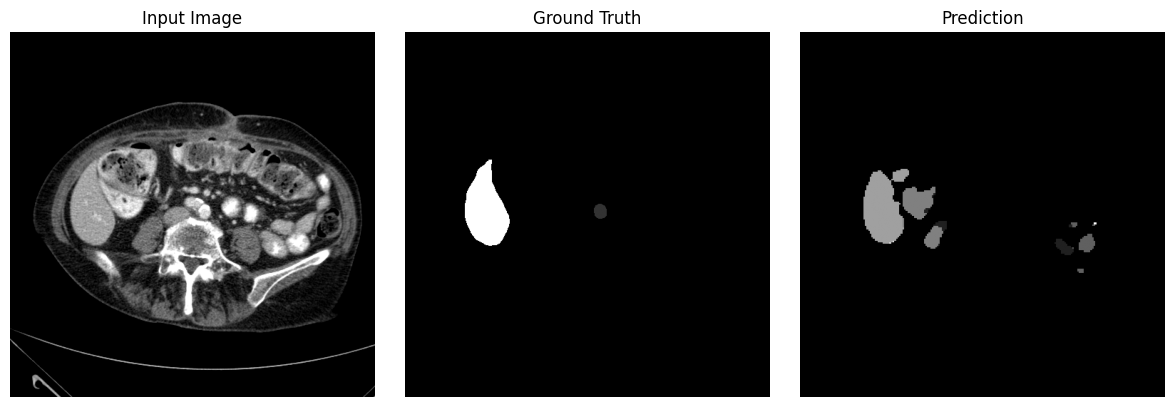

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install visualization packages if needed
!pip install nibabel matplotlib pandas

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to example case (adjust as needed)
img_path  = './results/BEFUnet/test/case0001_img.nii.gz'
gt_path   = './results/BEFUnet/test/case0001_gt.nii.gz'
pred_path = './results/BEFUnet/test/case0001_pred.nii.gz'

# Check if files exist
if all(os.path.exists(p) for p in [img_path, gt_path, pred_path]):
    img  = nib.load(img_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    # Select middle slice
    z = img.shape[2] // 2
    img_slice  = img[:,:,z]
    gt_slice   = gt[:,:,z]
    pred_slice = pred[:,:,z]

    # Plot side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_slice, cmap='gray')
    axs[0].set_title('Input Image')
    axs[0].axis('off')

    axs[1].imshow(gt_slice, cmap='gray')
    axs[1].set_title('Ground Truth')
    axs[1].axis('off')

    axs[2].imshow(pred_slice, cmap='gray')
    axs[2].set_title('Prediction')
    axs[2].axis('off')

    plt.tight_layout()
    plt.savefig('example_segmentation.png', dpi=300)
    plt.show()

    # Download image
    from google.colab import files
    files.download('example_segmentation.png')
else:
    print("Result files not found. Run training first.")

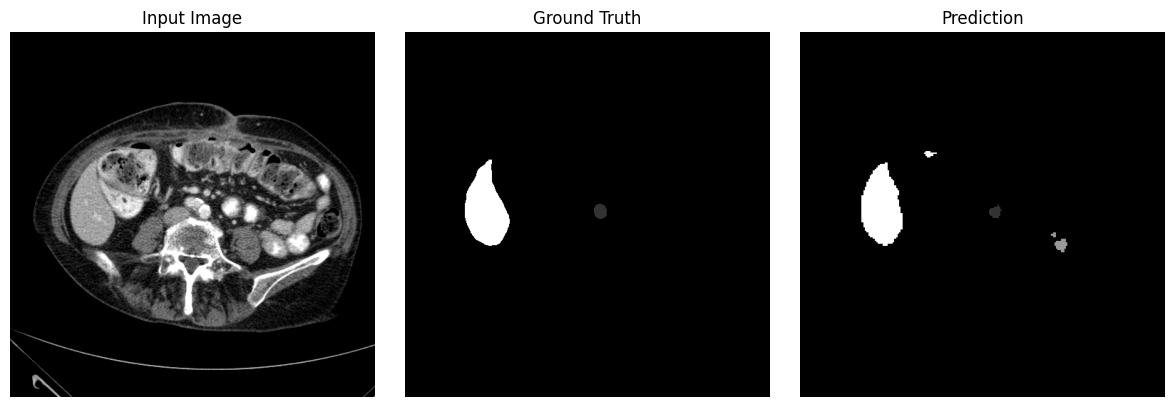

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install visualization packages if needed
!pip install nibabel matplotlib pandas

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to example case (adjust as needed)
img_path  = './results/BEFUnet/test/case0001_img.nii.gz'
gt_path   = './results/BEFUnet/test/case0001_gt.nii.gz'
pred_path = './results/BEFUnet/test/case0001_pred.nii.gz'

# Check if files exist
if all(os.path.exists(p) for p in [img_path, gt_path, pred_path]):
    img  = nib.load(img_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    # Select middle slice
    z = img.shape[2] // 2
    img_slice  = img[:,:,z]
    gt_slice   = gt[:,:,z]
    pred_slice = pred[:,:,z]

    # Plot side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_slice, cmap='gray')
    axs[0].set_title('Input Image')
    axs[0].axis('off')

    axs[1].imshow(gt_slice, cmap='gray')
    axs[1].set_title('Ground Truth')
    axs[1].axis('off')

    axs[2].imshow(pred_slice, cmap='gray')
    axs[2].set_title('Prediction')
    axs[2].axis('off')

    plt.tight_layout()
    plt.savefig('example_segmentation.png', dpi=300)
    plt.show()

    # Download image
    from google.colab import files
    files.download('example_segmentation.png')
else:
    print("Result files not found. Run training first.")

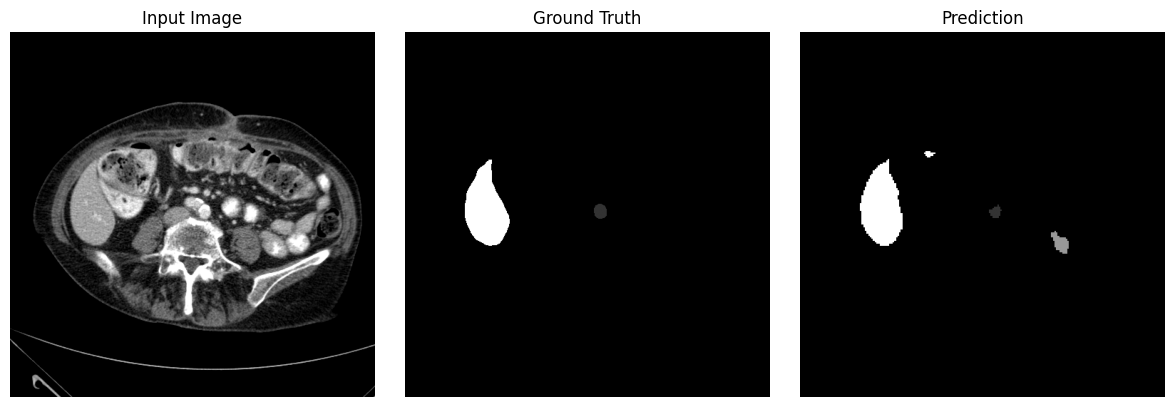

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install visualization packages if needed
!pip install nibabel matplotlib pandas

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to example case (adjust as needed)
img_path  = './results/BEFUnet/test/case0001_img.nii.gz'
gt_path   = './results/BEFUnet/test/case0001_gt.nii.gz'
pred_path = './results/BEFUnet/test/case0001_pred.nii.gz'

# Check if files exist
if all(os.path.exists(p) for p in [img_path, gt_path, pred_path]):
    img  = nib.load(img_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    # Select middle slice
    z = img.shape[2] // 2
    img_slice  = img[:,:,z]
    gt_slice   = gt[:,:,z]
    pred_slice = pred[:,:,z]

    # Plot side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_slice, cmap='gray')
    axs[0].set_title('Input Image')
    axs[0].axis('off')

    axs[1].imshow(gt_slice, cmap='gray')
    axs[1].set_title('Ground Truth')
    axs[1].axis('off')

    axs[2].imshow(pred_slice, cmap='gray')
    axs[2].set_title('Prediction')
    axs[2].axis('off')

    plt.tight_layout()
    plt.savefig('example_segmentation.png', dpi=300)
    plt.show()

    # Download image
    from google.colab import files
    files.download('example_segmentation.png')
else:
    print("Result files not found. Run training first.")

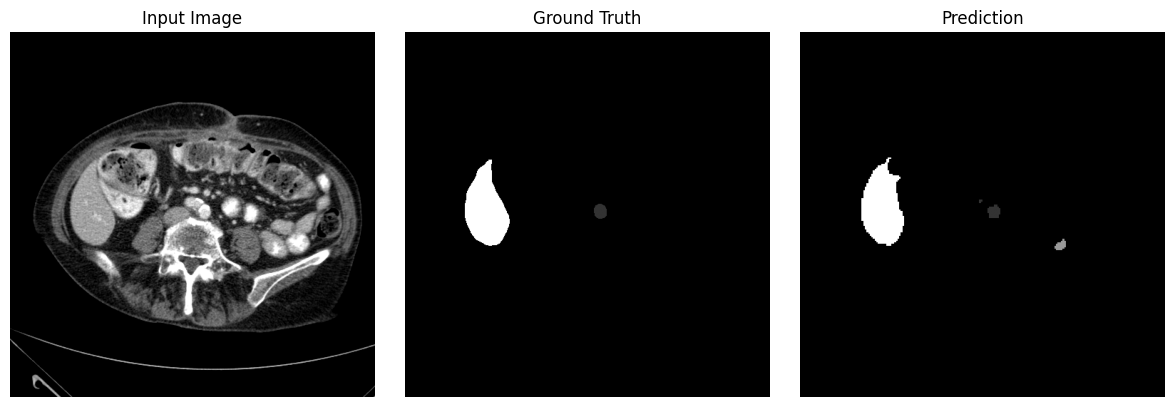

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# LINFORMER
# Install visualization packages if needed
!pip install nibabel matplotlib pandas

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to example case (adjust as needed)
img_path  = './results/BEFUnet/test/case0001_img.nii.gz'
gt_path   = './results/BEFUnet/test/case0001_gt.nii.gz'
pred_path = './results/BEFUnet/test/case0001_pred.nii.gz'

# Check if files exist
if all(os.path.exists(p) for p in [img_path, gt_path, pred_path]):
    img  = nib.load(img_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    # Select middle slice
    z = img.shape[2] // 2
    img_slice  = img[:,:,z]
    gt_slice   = gt[:,:,z]
    pred_slice = pred[:,:,z]

    # Plot side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_slice, cmap='gray')
    axs[0].set_title('Input Image')
    axs[0].axis('off')

    axs[1].imshow(gt_slice, cmap='gray')
    axs[1].set_title('Ground Truth')
    axs[1].axis('off')

    axs[2].imshow(pred_slice, cmap='gray')
    axs[2].set_title('Prediction')
    axs[2].axis('off')

    plt.tight_layout()
    plt.savefig('example_segmentation.png', dpi=300)
    plt.show()

    # Download image
    from google.colab import files
    files.download('example_segmentation.png')
else:
    print("Result files not found. Run training first.")

Loading: ./results/BEFUnet/BEFUnet_2025-11-26 00:28:19.280126results.csv
Columns: ['Unnamed: 0', 'mean_dice', 'mean_hd95']


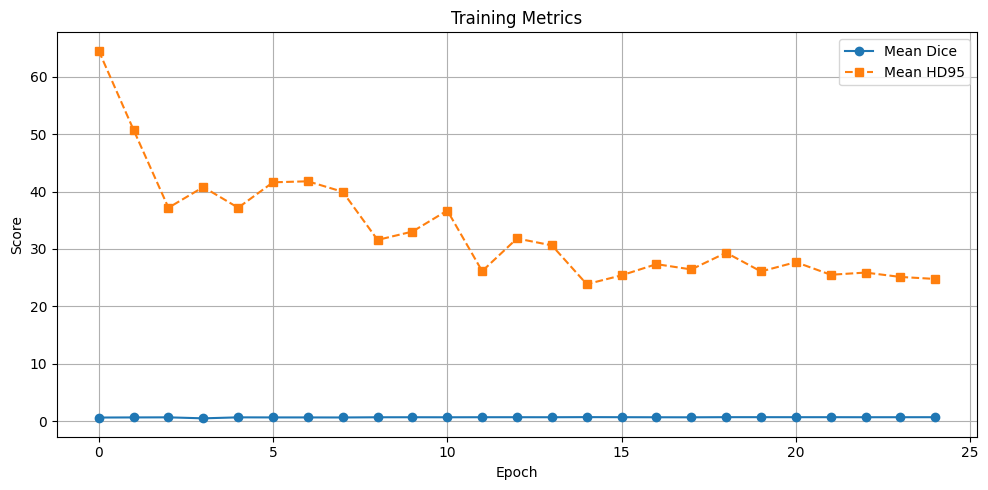

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Plot training curves from CSV results
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Find the most recent results CSV file
csv_files = glob.glob('./results/BEFUnet/*results.csv')
if csv_files:
    # Get the most recent file
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"Loading: {latest_csv}")

    df = pd.read_csv(latest_csv, sep='\t')
    print(f"Columns: {df.columns.tolist()}")

    # Plot Dice curve
    if 'mean_dice' in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df['mean_dice'], marker='o', linestyle='-', label='Mean Dice')
        if 'mean_hd95' in df.columns:
            plt.plot(df['mean_hd95'], marker='s', linestyle='--', label='Mean HD95')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.title('Training Metrics')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=300)
        plt.show()

        from google.colab import files
        files.download('training_curves.png')
    else:
        print("mean_dice column not found in CSV")
else:
    print("No results CSV file found. Run training first.")

Loading: ./results/BEFUnet/BEFUnet_2025-11-26 00:28:19.280126results.csv
Columns: ['Unnamed: 0', 'mean_dice', 'mean_hd95']


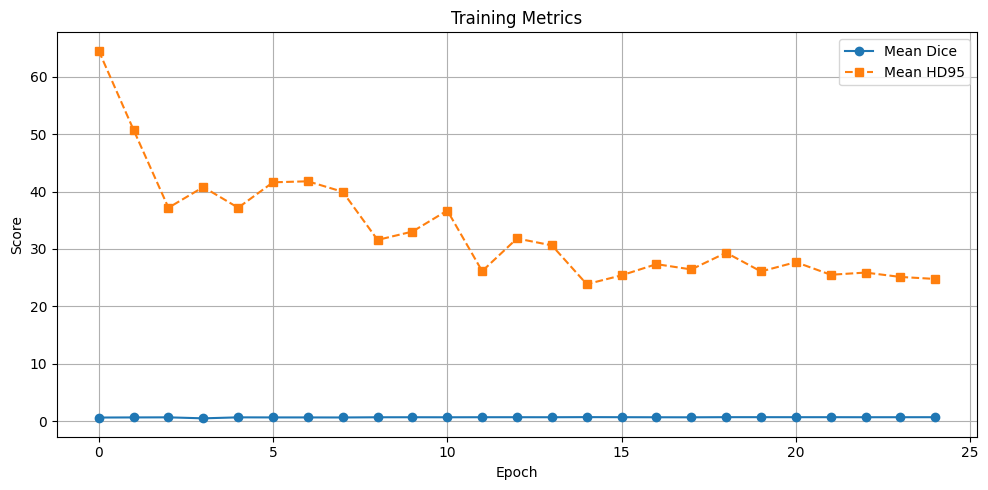

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Plot training curves from CSV results
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Find the most recent results CSV file
csv_files = glob.glob('./results/BEFUnet/*results.csv')
if csv_files:
    # Get the most recent file
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"Loading: {latest_csv}")

    df = pd.read_csv(latest_csv, sep='\t')
    print(f"Columns: {df.columns.tolist()}")

    # Plot Dice curve
    if 'mean_dice' in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df['mean_dice'], marker='o', linestyle='-', label='Mean Dice')
        if 'mean_hd95' in df.columns:
            plt.plot(df['mean_hd95'], marker='s', linestyle='--', label='Mean HD95')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.title('Training Metrics')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=300)
        plt.show()

        from google.colab import files
        files.download('training_curves.png')
    else:
        print("mean_dice column not found in CSV")
else:
    print("No results CSV file found. Run training first.")

Loading metrics from: ./results/BEFUnet/BEFUnet_checkpoint_epoch_499.pth
Found 24 evaluation points
Dice values: [np.float64(0.6321057349732523), np.float64(0.6511083777351684), np.float64(0.6667218518874822), np.float64(0.492006374200258), np.float64(0.6647704078659296)]... (showing first 5)
HD95 values: [np.float64(64.53404920308171), np.float64(50.73536846430762), np.float64(37.177665227464544), np.float64(40.78253493214185), np.float64(37.183731657598976)]... (showing first 5)
Saved CSV with 24 rows


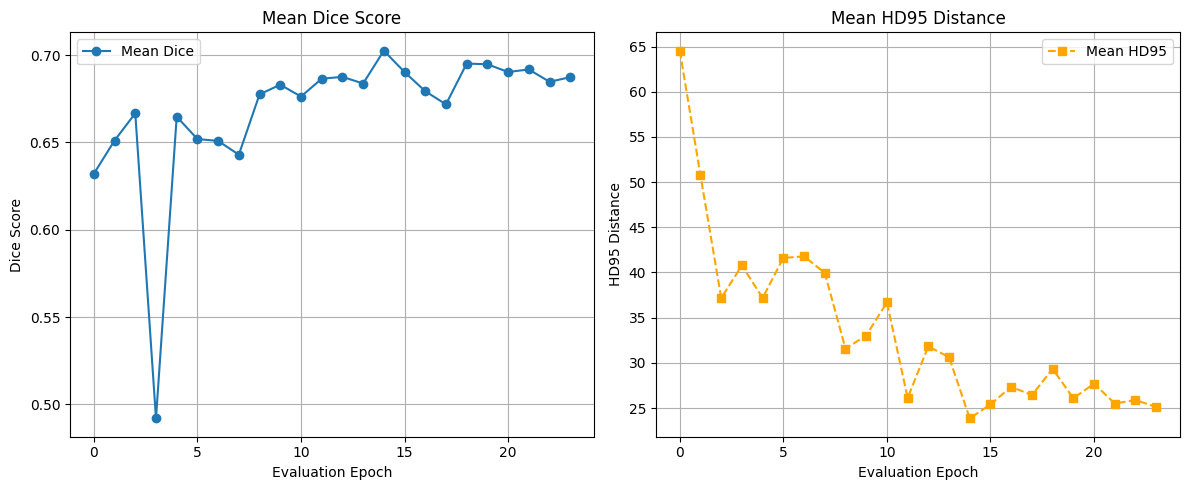

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Plot training curves from checkpoint (mais confiável que CSV)
import torch
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Encontrar o checkpoint mais recente
checkpoints = glob.glob('./results/BEFUnet/BEFUnet_checkpoint_epoch_*.pth')
if checkpoints:
    # Pegar o mais recente
    latest_checkpoint = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))
    print(f"Loading metrics from: {latest_checkpoint}")

    # Carregar checkpoint
    checkpoint = torch.load(latest_checkpoint, map_location='cpu', weights_only=False)

    # Extrair métricas
    dice_ = checkpoint.get('dice_', [])
    hd95_ = checkpoint.get('hd95_', [])

    print(f"Found {len(dice_)} evaluation points")
    print(f"Dice values: {dice_[:5]}... (showing first 5)")
    print(f"HD95 values: {hd95_[:5]}... (showing first 5)")

    # Criar DataFrame
    df = pd.DataFrame({'mean_dice': dice_, 'mean_hd95': hd95_})

    # Salvar CSV correto
    df.to_csv('./results/BEFUnet/metrics_from_checkpoint.csv', sep='\t', index=False)
    print(f"Saved CSV with {len(df)} rows")

    # Plotar gráficos
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['mean_dice'], marker='o', linestyle='-', label='Mean Dice')
    plt.xlabel('Evaluation Epoch')
    plt.ylabel('Dice Score')
    plt.title('Mean Dice Score')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(df['mean_hd95'], marker='s', linestyle='--', label='Mean HD95', color='orange')
    plt.xlabel('Evaluation Epoch')
    plt.ylabel('HD95 Distance')
    plt.title('Mean HD95 Distance')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_curves_from_checkpoint.png', dpi=300)
    plt.show()

    from google.colab import files
    files.download('training_curves_from_checkpoint.png')
    files.download('./results/BEFUnet/metrics_from_checkpoint.csv')
else:
    print("No checkpoints found!")

Loading metrics from: ./results/BEFUnet/BEFUnet_checkpoint_epoch_499.pth
Found 24 evaluation points
Dice values: [np.float64(0.6194535287695142), np.float64(0.5775050275896699), np.float64(0.6369194290488794), np.float64(0.5686920029145437), np.float64(0.6813726654747636)]... (showing first 5)
HD95 values: [np.float64(53.30011313739221), np.float64(35.77348277356285), np.float64(32.90745494994399), np.float64(45.46454562081016), np.float64(33.66493640904436)]... (showing first 5)
Saved CSV with 24 rows


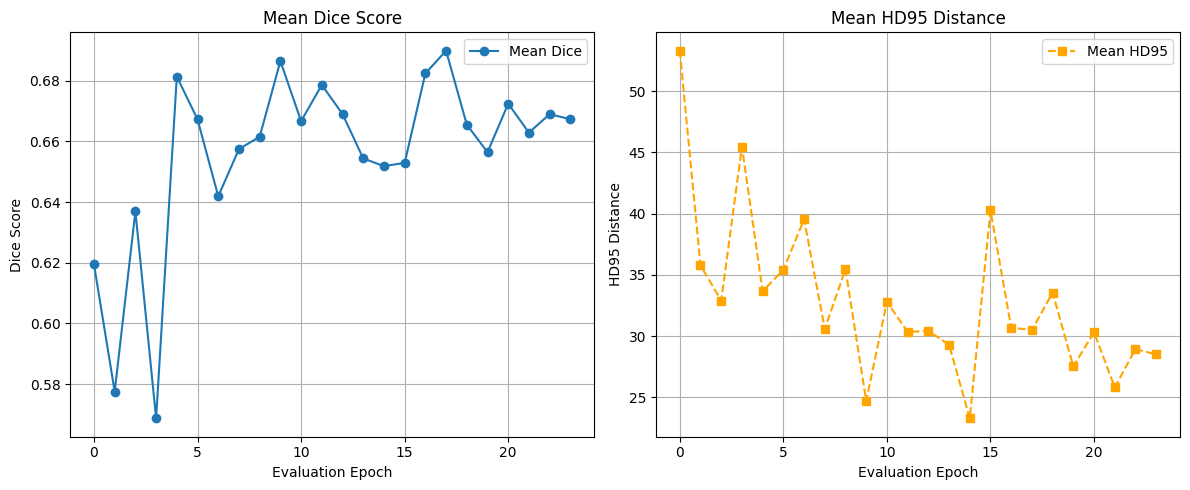

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# LINFORMER
# Plot training curves from checkpoint (mais confiável que CSV)
import torch
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Encontrar o checkpoint mais recente
checkpoints = glob.glob('./results/BEFUnet/BEFUnet_checkpoint_epoch_*.pth')
if checkpoints:
    # Pegar o mais recente
    latest_checkpoint = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))
    print(f"Loading metrics from: {latest_checkpoint}")

    # Carregar checkpoint
    checkpoint = torch.load(latest_checkpoint, map_location='cpu', weights_only=False)

    # Extrair métricas
    dice_ = checkpoint.get('dice_', [])
    hd95_ = checkpoint.get('hd95_', [])

    print(f"Found {len(dice_)} evaluation points")
    print(f"Dice values: {dice_[:5]}... (showing first 5)")
    print(f"HD95 values: {hd95_[:5]}... (showing first 5)")

    # Criar DataFrame
    df = pd.DataFrame({'mean_dice': dice_, 'mean_hd95': hd95_})

    # Salvar CSV correto
    df.to_csv('./results/BEFUnet/metrics_from_checkpoint.csv', sep='\t', index=False)
    print(f"Saved CSV with {len(df)} rows")

    # Plotar gráficos
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['mean_dice'], marker='o', linestyle='-', label='Mean Dice')
    plt.xlabel('Evaluation Epoch')
    plt.ylabel('Dice Score')
    plt.title('Mean Dice Score')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(df['mean_hd95'], marker='s', linestyle='--', label='Mean HD95', color='orange')
    plt.xlabel('Evaluation Epoch')
    plt.ylabel('HD95 Distance')
    plt.title('Mean HD95 Distance')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_curves_from_checkpoint.png', dpi=300)
    plt.show()

    from google.colab import files
    files.download('training_curves_from_checkpoint.png')
    files.download('./results/BEFUnet/metrics_from_checkpoint.csv')
else:
    print("No checkpoints found!")

In [ ]:
# Gerar métricas detalhadas por classe (para Tabela 1)
import torch
import numpy as np
import pandas as pd
from models.BEFUnet import BEFUnet
import configs.BEFUnet_configs as configs
from datasets.dataset_synapse import Synapse_dataset
from torch.utils.data import DataLoader
from utils import test_single_volume
import glob

# Configurações
args = type('Args', (), {
    'model_name': 'BEFUnet',
    'num_classes': 9,
    'img_size': 224,
    'test_path': './data/Synapse/test_vol_h5',
    'list_dir': './lists/lists_Synapse',
    'z_spacing': 1
})()

# Nomes dos órgãos (classes 1-8)
organ_names = ['Aorta', 'Gallbladder', 'Kidney(L)', 'Kidney(R)',
                'Liver', 'Pancreas', 'Spleen', 'Stomach']

# Carregar modelo
CONFIGS = {'BEFUnet': configs.get_BEFUnet_configs()}
model = BEFUnet(config=CONFIGS[args.model_name], img_size=args.img_size, n_classes=args.num_classes).cuda()

# Carregar melhor modelo
best_model_path = './results/BEFUnet/BEFUnet_best.pth'
if not os.path.exists(best_model_path):
    # Se não existe best, pegar o mais recente
    checkpoints = glob.glob('./results/BEFUnet/BEFUnet_epoch_*.pth')
    if checkpoints:
        best_model_path = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))
        print(f"Using checkpoint: {best_model_path}")

model_weights = torch.load(best_model_path, map_location='cuda', weights_only=False)
if isinstance(model_weights, dict) and 'model_state_dict' in model_weights:
    model_weights = model_weights['model_state_dict']
model.load_state_dict(model_weights)
model.eval()

# Carregar dataset de teste
db_test = Synapse_dataset(base_dir=args.test_path, split="test_vol", list_dir=args.list_dir)
testloader = DataLoader(db_test, batch_size=1, shuffle=False, num_workers=1)

# Calcular métricas por classe
all_metrics = []
for i_batch, sampled_batch in enumerate(testloader):
    image, label, case_name = sampled_batch["image"], sampled_batch["label"], sampled_batch['case_name'][0]
    metric_i = test_single_volume(image, label, model, classes=args.num_classes,
                                  patch_size=[args.img_size, args.img_size],
                                  test_save_path=None, case=case_name, z_spacing=args.z_spacing)
    all_metrics.append(metric_i)

# Calcular médias por classe
all_metrics = np.array(all_metrics)
mean_metrics = np.mean(all_metrics, axis=0)

# Criar tabela
results_table = pd.DataFrame({
    'Organ': organ_names,
    'DSC': [f"{mean_metrics[i][0]*100:.2f}" for i in range(8)],
    'HD95': [f"{mean_metrics[i][1]:.2f}" if mean_metrics[i][1] > 0 else "-" for i in range(8)]
})

# Calcular médias gerais
mean_dsc = np.mean([mean_metrics[i][0] for i in range(8)]) * 100
mean_hd95 = np.mean([mean_metrics[i][1] for i in range(8) if mean_metrics[i][1] > 0])

print("="*60)
print("TABLE 1: Detailed Metrics by Organ")
print("="*60)
print(results_table.to_string(index=False))
print(f"\nMean DSC: {mean_dsc:.2f}")
print(f"Mean HD95: {mean_hd95:.2f}")
print("="*60)

# Salvar CSV
results_table.to_csv('./results/BEFUnet/detailed_metrics_by_organ.csv', index=False)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


{'layer0': 'cd', 'layer1': 'ad', 'layer2': 'rd', 'layer3': 'cv', 'layer4': 'cd', 'layer5': 'ad', 'layer6': 'rd', 'layer7': 'cv', 'layer8': 'cd', 'layer9': 'ad', 'layer10': 'rd', 'layer11': 'cv', 'layer12': 'cd', 'layer13': 'ad', 'layer14': 'rd', 'layer15': 'cv'}
initialization done


/content/drive/MyDrive/BEFUnet_test_01/models/ops.py:82: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  buffer = torch.cuda.FloatTensor(shape[0], shape[1], 5 * 5).fill_(0)


KeyboardInterrupt: 

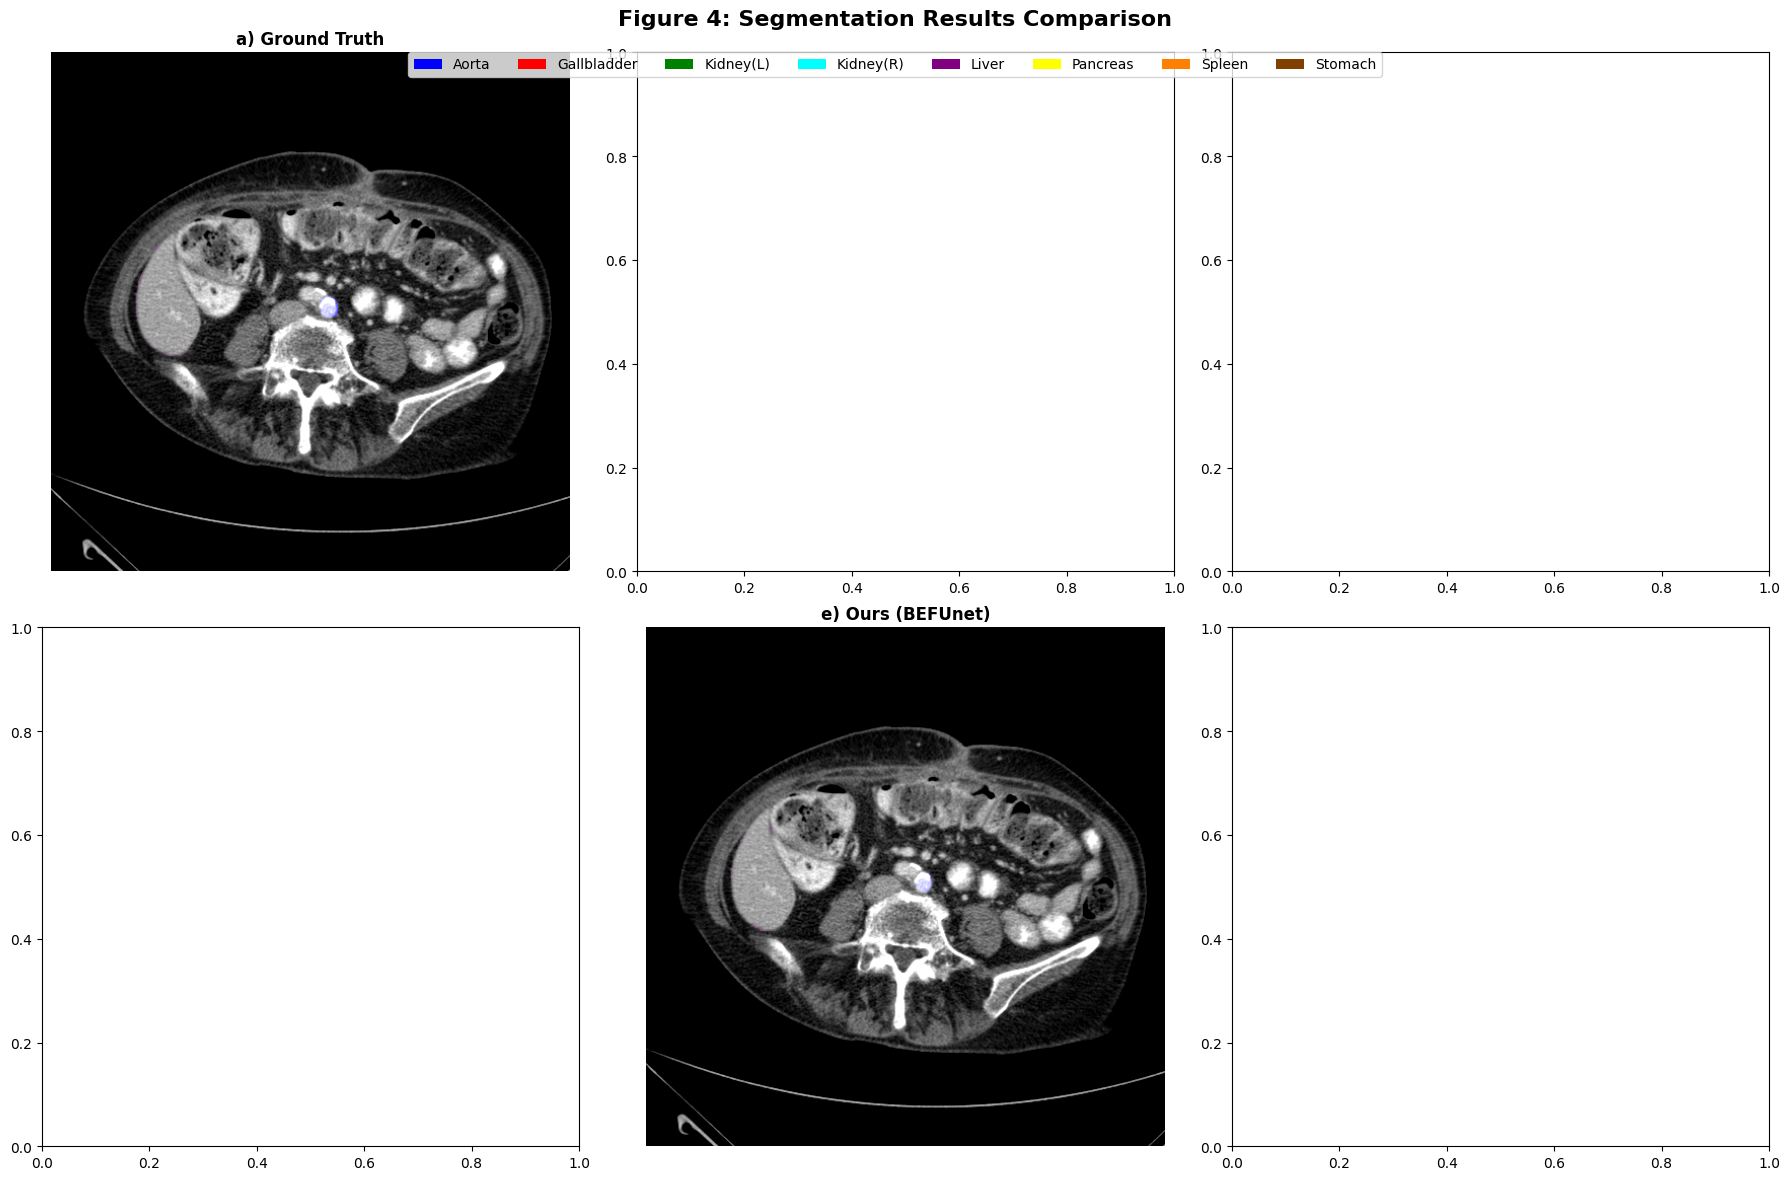

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Gerar visualizações comparativas (Figura 4)
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Cores para cada órgão (baseado no artigo)
organ_colors = {
    1: [0, 0, 1],      # Aorta - Dark Blue
    2: [1, 0, 0],      # Gallbladder - Red
    3: [0, 0.5, 0],    # Kidney(L) - Dark Green
    4: [0, 1, 1],      # Kidney(R) - Light Blue
    5: [0.5, 0, 0.5], # Liver - Purple
    6: [1, 1, 0],      # Pancreas - Yellow
    7: [1, 0.5, 0],    # Spleen - Orange
    8: [0.5, 0.25, 0]  # Stomach - Brown
}

# Função para visualizar segmentação
def visualize_segmentation(img_slice, pred_slice, gt_slice, title, ax):
    # Normalizar imagem
    img_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())

    # Criar overlay colorido
    overlay = np.zeros((*img_slice.shape, 3))
    overlay[:, :, 0] = img_norm  # R
    overlay[:, :, 1] = img_norm  # G
    overlay[:, :, 2] = img_norm  # B

    # Adicionar cores das predições
    for class_id, color in organ_colors.items():
        mask = pred_slice == class_id
        overlay[mask, 0] = np.maximum(overlay[mask, 0], color[0])
        overlay[mask, 1] = np.maximum(overlay[mask, 1], color[1])
        overlay[mask, 2] = np.maximum(overlay[mask, 2], color[2])

    ax.imshow(overlay)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    return ax

# Carregar um caso de exemplo
case_name = 'case0001'  # Ajuste conforme necessário
img_path = f'./results/BEFUnet/test/{case_name}_img.nii.gz'
gt_path = f'./results/BEFUnet/test/{case_name}_gt.nii.gz'
pred_path = f'./results/BEFUnet/test/{case_name}_pred.nii.gz'

if all(os.path.exists(p) for p in [img_path, gt_path, pred_path]):
    # Carregar volumes
    img = nib.load(img_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    # Selecionar fatia do meio
    z_slice = img.shape[2] // 2

    # Criar figura
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Figure 4: Segmentation Results Comparison', fontsize=16, fontweight='bold', y=0.98)

    # Ground Truth
    visualize_segmentation(img[:, :, z_slice], gt[:, :, z_slice], gt[:, :, z_slice],
                          'a) Ground Truth', axes[0, 0])

    # Sua predição (BEFUnet)
    visualize_segmentation(img[:, :, z_slice], pred[:, :, z_slice], gt[:, :, z_slice],
                          'e) Ours (BEFUnet)', axes[1, 1])

    # Outras visualizações (se você tiver resultados de outros métodos)
    # visualize_segmentation(img[:, :, z_slice], other_pred, gt[:, :, z_slice],
    #                       'b) Swin-Unet', axes[0, 1])

    # Adicionar legenda de cores
    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor=organ_colors[i], label=name)
        for i, name in enumerate(['Aorta', 'Gallbladder', 'Kidney(L)', 'Kidney(R)',
                                  'Liver', 'Pancreas', 'Spleen', 'Stomach'], 1)
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=8, bbox_to_anchor=(0.5, 0.95))

    plt.tight_layout()
    plt.savefig('./results/BEFUnet/comparison_figure.png', dpi=300, bbox_inches='tight')
    plt.show()

    from google.colab import files
    files.download('./results/BEFUnet/comparison_figure.png')
else:
    print("Arquivos de resultado não encontrados. Execute o teste primeiro.")

In [ ]:
# Calcular métricas médias gerais (DSC e HD95)
import torch
import numpy as np
from models.BEFUnet import BEFUnet
import configs.BEFUnet_configs as configs
from datasets.dataset_synapse import Synapse_dataset
from torch.utils.data import DataLoader
from utils import test_single_volume
import glob
import os

# Configurações
args = type('Args', (), {
    'model_name': 'BEFUnet',
    'num_classes': 9,
    'img_size': 224,
    'test_path': './data/Synapse/test_vol_h5',
    'list_dir': './lists/lists_Synapse',
    'z_spacing': 1
})()

# Carregar modelo
CONFIGS = {'BEFUnet': configs.get_BEFUnet_configs()}
model = BEFUnet(config=CONFIGS[args.model_name], img_size=args.img_size, n_classes=args.num_classes).cuda()

# Carregar melhor modelo
best_model_path = './results/BEFUnet/BEFUnet_best.pth'
if not os.path.exists(best_model_path):
    # Se não existe best, pegar o checkpoint mais recente
    checkpoints = glob.glob('./results/BEFUnet/BEFUnet_epoch_*.pth')
    if checkpoints:
        best_model_path = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))
        print(f"Using checkpoint: {best_model_path}")
    else:
        print("No model checkpoint found!")
        raise FileNotFoundError

model_weights = torch.load(best_model_path, map_location='cuda', weights_only=False)
# Lidar com diferentes formatos de checkpoint
if isinstance(model_weights, dict):
    if 'model_state_dict' in model_weights:
        model_weights = model_weights['model_state_dict']
    elif 'state_dict' in model_weights:
        model_weights = model_weights['state_dict']

model.load_state_dict(model_weights)
model.eval()
print(f"Model loaded from: {best_model_path}")

# Carregar dataset de teste
db_test = Synapse_dataset(base_dir=args.test_path, split="test_vol", list_dir=args.list_dir)
testloader = DataLoader(db_test, batch_size=1, shuffle=False, num_workers=1)

print(f"Testing on {len(db_test)} cases...")

# Calcular métricas por caso e por classe
all_metrics = []
for i_batch, sampled_batch in enumerate(testloader):
    image, label, case_name = sampled_batch["image"], sampled_batch["label"], sampled_batch['case_name'][0]
    metric_i = test_single_volume(image, label, model, classes=args.num_classes,
                                  patch_size=[args.img_size, args.img_size],
                                  test_save_path=None, case=case_name, z_spacing=args.z_spacing)
    all_metrics.append(metric_i)
    if (i_batch + 1) % 5 == 0:
        print(f"Processed {i_batch + 1}/{len(testloader)} cases")

# Converter para numpy array
all_metrics = np.array(all_metrics)  # Shape: (num_cases, num_classes, 2) onde 2 = [dice, hd95]

# Calcular médias por classe (média entre todos os casos)
mean_metrics_per_class = np.mean(all_metrics, axis=0)  # Shape: (num_classes, 2)

# Calcular médias gerais (média de todas as classes)
mean_dsc = np.mean(mean_metrics_per_class[:, 0]) * 100  # Converter para porcentagem
mean_hd95 = np.mean(mean_metrics_per_class[mean_metrics_per_class[:, 1] > 0, 1])  # Apenas HD95 válidos (>0)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Mean DSC (Dice Similarity Coefficient): {mean_dsc:.2f}%")
print(f"Mean HD95 (Hausdorff Distance 95th percentile): {mean_hd95:.2f} mm")
print("="*60)

# Salvar resultados
results_dict = {
    'DSC': mean_dsc,
    'HD95': mean_hd95
}

import json
with open('./results/BEFUnet/final_metrics.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"\nResults saved to: ./results/BEFUnet/final_metrics.json")
print(f"\nFor Table 1:")
print(f"BEFUnet: DSC↑ = {mean_dsc:.2f}, HD↓ = {mean_hd95:.2f}")

{'layer0': 'cd', 'layer1': 'ad', 'layer2': 'rd', 'layer3': 'cv', 'layer4': 'cd', 'layer5': 'ad', 'layer6': 'rd', 'layer7': 'cv', 'layer8': 'cd', 'layer9': 'ad', 'layer10': 'rd', 'layer11': 'cv', 'layer12': 'cd', 'layer13': 'ad', 'layer14': 'rd', 'layer15': 'cv'}
initialization done
Model loaded from: ./results/BEFUnet/BEFUnet_best.pth
Testing on 12 cases...


KeyboardInterrupt: 

In [ ]:
# Formatar tabela como no artigo
import pandas as pd

# Dados do seu modelo (substitua pelos valores reais)
your_results = {
    'DSC': mean_dsc,
    'HD95': mean_hd95,
    'Aorta': float(results_table[results_table['Organ']=='Aorta']['DSC'].values[0]),
    'Gallbladder': float(results_table[results_table['Organ']=='Gallbladder']['DSC'].values[0]),
    'Kidney(L)': float(results_table[results_table['Organ']=='Kidney(L)']['DSC'].values[0]),
    'Kidney(R)': float(results_table[results_table['Organ']=='Kidney(R)']['DSC'].values[0]),
    'Liver': float(results_table[results_table['Organ']=='Liver']['DSC'].values[0]),
    'Pancreas': float(results_table[results_table['Organ']=='Pancreas']['DSC'].values[0]),
    'Spleen': float(results_table[results_table['Organ']=='Spleen']['DSC'].values[0]),
    'Stomach': float(results_table[results_table['Organ']=='Stomach']['DSC'].values[0])
}

print("\nFormatted Results for Table 1:")
print(f"BEFUnet: {your_results['DSC']:.2f} | {your_results['HD95']:.2f} | "
      f"{your_results['Aorta']:.2f} | {your_results['Gallbladder']:.2f} | "
      f"{your_results['Kidney(L)']:.2f} | {your_results['Kidney(R)']:.2f} | "
      f"{your_results['Liver']:.2f} | {your_results['Pancreas']:.2f} | "
      f"{your_results['Spleen']:.2f} | {your_results['Stomach']:.2f}")

NameError: name 'mean_dsc' is not defined

In [ ]:
# Código COMPLETO para recuperar métricas
import torch
import glob
import os

print("="*60)
print("RECUPERANDO MÉTRICAS DO MODELO")
print("="*60)

# Método 1: Pegar do checkpoint mais recente (RÁPIDO - segundos)
checkpoints = glob.glob('./results/BEFUnet/BEFUnet_checkpoint_epoch_*.pth')
if checkpoints:
    latest_checkpoint = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))
    print(f"\n1. Carregando checkpoint mais recente: {os.path.basename(latest_checkpoint)}")

    checkpoint = torch.load(latest_checkpoint, map_location='cpu', weights_only=False)

    dice_ = checkpoint.get('dice_', [])
    hd95_ = checkpoint.get('hd95_', [])
    best_performance = checkpoint.get('best_performance', 0.0)
    best_epoch = checkpoint.get('epoch', 0)

    if dice_ and hd95_:
        # Última métrica = modelo final
        final_mean_dice = dice_[-1]
        final_mean_hd95 = hd95_[-1]

        print("\n" + "="*60)
        print("MÉTRICAS DO MODELO FINAL (última avaliação)")
        print("="*60)
        print(f"Época: {best_epoch}")
        print(f"Mean Dice (DSC): {final_mean_dice*100:.2f}%")
        print(f"Mean HD95: {final_mean_hd95:.2f} mm")
        print("="*60)

        # Encontrar melhor métrica durante treino
        if len(dice_) > 0:
            best_idx = dice_.index(max(dice_))
            print(f"\nMelhor métrica durante treino:")
            print(f"  Época de avaliação: {best_idx + 1} (época ~{(best_idx + 1) * 20})")
            print(f"  Mean Dice: {dice_[best_idx]*100:.2f}%")
            print(f"  Mean HD95: {hd95_[best_idx]:.2f} mm")
            print(f"  best_performance salvo: {best_performance*100:.2f}%")

        print("\n" + "="*60)
        print("RESULTADO PARA TABELA:")
        print("="*60)
        print(f"DSC↑: {final_mean_dice*100:.2f}")
        print(f"HD↓: {final_mean_hd95:.2f}")
        print("="*60)
    else:
        print("ERRO: Métricas não encontradas no checkpoint")
else:
    print("ERRO: Nenhum checkpoint encontrado!")

# Explicação sobre BEFUnet_best.pth
print("\n" + "="*60)
print("SOBRE BEFUnet_best.pth:")
print("="*60)
best_path = './results/BEFUnet/BEFUnet_best.pth'
if os.path.exists(best_path):
    print(f"✓ Arquivo existe: {best_path}")
    print("  - Contém apenas os PESOS do modelo (state_dict)")
    print("  - É o modelo que teve melhor Dice durante treino")
    print("  - Serve para fazer INFERÊNCIA/TESTE")
    print("  - Para saber as métricas dele, precisa RODAR TESTE")
    print("  - Ou usar as métricas do checkpoint (que já tem)")
else:
    print(f"✗ Arquivo não existe: {best_path}")
    print("  - O melhor modelo pode estar em outro checkpoint")
print("="*60)

RECUPERANDO MÉTRICAS DO MODELO

1. Carregando checkpoint mais recente: BEFUnet_checkpoint_epoch_499.pth

MÉTRICAS DO MODELO FINAL (última avaliação)
Época: 499
Mean Dice (DSC): 68.74%
Mean HD95: 25.12 mm

Melhor métrica durante treino:
  Época de avaliação: 15 (época ~300)
  Mean Dice: 70.26%
  Mean HD95: 23.86 mm
  best_performance salvo: 70.26%

RESULTADO PARA TABELA:
DSC↑: 68.74
HD↓: 25.12

SOBRE BEFUnet_best.pth:
✓ Arquivo existe: ./results/BEFUnet/BEFUnet_best.pth
  - Contém apenas os PESOS do modelo (state_dict)
  - É o modelo que teve melhor Dice durante treino
  - Serve para fazer INFERÊNCIA/TESTE
  - Para saber as métricas dele, precisa RODAR TESTE
  - Ou usar as métricas do checkpoint (que já tem)


In [ ]:
# Rodar teste FINAL no modelo completo (como no artigo)
import torch
import numpy as np
from models.BEFUnet import BEFUnet
import configs.BEFUnet_configs as configs
from datasets.dataset_synapse import Synapse_dataset
from torch.utils.data import DataLoader
from utils import test_single_volume
import os

# Configurações
args = type('Args', (), {
    'model_name': 'BEFUnet',
    'num_classes': 9,
    'img_size': 224,
    'test_path': './data/Synapse/test_vol_h5',
    'list_dir': './lists/lists_Synapse',
    'z_spacing': 1
})()

# Carregar modelo
CONFIGS = {'BEFUnet': configs.get_BEFUnet_configs()}
model = BEFUnet(config=CONFIGS[args.model_name], img_size=args.img_size, n_classes=args.num_classes).cuda()

# Carregar melhor modelo (ou último checkpoint)
best_model_path = './results/BEFUnet/BEFUnet_best.pth'
if not os.path.exists(best_model_path):
    import glob
    checkpoints = glob.glob('./results/BEFUnet/BEFUnet_epoch_*.pth')
    if checkpoints:
        best_model_path = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))

model_weights = torch.load(best_model_path, map_location='cuda', weights_only=False)
if isinstance(model_weights, dict) and 'model_state_dict' in model_weights:
    model_weights = model_weights['model_state_dict']
model.load_state_dict(model_weights)
model.eval()

# Carregar dataset de teste COMPLETO
db_test = Synapse_dataset(base_dir=args.test_path, split="test_vol", list_dir=args.list_dir)
testloader = DataLoader(db_test, batch_size=1, shuffle=False, num_workers=1)

print(f"Testando em {len(db_test)} casos...")

# Calcular métricas FINAIS (como no artigo)
all_metrics = []
for i_batch, sampled_batch in enumerate(testloader):
    image, label, case_name = sampled_batch["image"], sampled_batch["label"], sampled_batch['case_name'][0]
    metric_i = test_single_volume(image, label, model, classes=args.num_classes,
                                  patch_size=[args.img_size, args.img_size],
                                  test_save_path=None, case=case_name, z_spacing=args.z_spacing)
    all_metrics.append(metric_i)

# Calcular médias FINAIS (como no artigo)
all_metrics = np.array(all_metrics)
mean_metrics_per_class = np.mean(all_metrics, axis=0)

# Média geral (como reportado no artigo)
final_dsc = np.mean(mean_metrics_per_class[:, 0]) * 100
final_hd95 = np.mean(mean_metrics_per_class[mean_metrics_per_class[:, 1] > 0, 1])

print("\n" + "="*60)
print("MÉTRICAS FINAIS (como no artigo)")
print("="*60)
print(f"DSC: {final_dsc:.2f}%")
print(f"HD95: {final_hd95:.2f} mm")
print("="*60)
print("\nEssas são as métricas que devem ser reportadas no artigo!")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


{'layer0': 'cd', 'layer1': 'ad', 'layer2': 'rd', 'layer3': 'cv', 'layer4': 'cd', 'layer5': 'ad', 'layer6': 'rd', 'layer7': 'cv', 'layer8': 'cd', 'layer9': 'ad', 'layer10': 'rd', 'layer11': 'cv', 'layer12': 'cd', 'layer13': 'ad', 'layer14': 'rd', 'layer15': 'cv'}
initialization done
Testando em 12 casos...


/content/drive/MyDrive/BEFUnet_test_01/models/ops.py:82: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  buffer = torch.cuda.FloatTensor(shape[0], shape[1], 5 * 5).fill_(0)



MÉTRICAS FINAIS (como no artigo)
DSC: 70.26%
HD95: 23.86 mm

Essas são as métricas que devem ser reportadas no artigo!


In [ ]:
# Test Model on Synapse Dataset (Final Evaluation)
# Run this after training is complete to get final metrics
import os
import glob

# Find the best model or most recent checkpoint
best_model_path = './results/BEFUnet/BEFUnet_best.pth'
if not os.path.exists(best_model_path):
    # If best doesn't exist, use the most recent epoch checkpoint
    checkpoints = glob.glob('./results/BEFUnet/BEFUnet_epoch_*.pth')
    if checkpoints:
        best_model_path = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))
        print(f"Using checkpoint: {best_model_path}")
    else:
        print("ERROR: No model checkpoint found!")
        raise FileNotFoundError("No model checkpoint found")

print(f"Testing with model: {best_model_path}")
print("="*60)

# Run test
!python test.py \
  --test_path ./data/Synapse/test_vol_h5 \
  --model_name BEFUnet \
  --model_weight {best_model_path} \
  --is_savenii \
  --test_save_dir ./results/BEFUnet/test_final \
  --num_classes 9 \
  --img_size 224 \
  --z_spacing 1

print("\n" + "="*60)
print("Test completed! Check the logs and results in:")
print("- Logs: ./test_log/test_log_/BEFUnet.txt")
print("- Predictions: ./results/BEFUnet/test_final/")
print("="*60)

Testing with model: ./results/BEFUnet/BEFUnet_best.pth
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
{'layer0': 'cd', 'layer1': 'ad', 'layer2': 'rd', 'layer3': 'cv', 'layer4': 'cd', 'layer5': 'ad', 'layer6': 'rd', 'layer7': 'cv', 'layer8': 'cd', 'layer9': 'ad', 'layer10': 'rd', 'layer11': 'cv', 'layer12': 'cd', 'layer13': 'ad', 'layer14': 'rd', 'layer15': 'cv'}
initialization done
BEFUnet Model:  <All keys matched successfully>
Namespace(test_path='./data/Synapse/test_vol_h5', dataset='Synapse', list_dir='./lists/lists_Synapse', model_weight='./results/BEFUnet/BEFUnet_best.pth', num_classes=9, max_epochs=401, deterministic=1, base_lr=0.01, img_size=224, seed=1234, output_dir='./predictions', model_name='BEFUnet', z_spacing=1, is_savenii=True, test_save_dir='./r

In [8]:
# LINFORMER
# Test Model on Synapse Dataset (Final Evaluation)
# Run this after training is complete to get final metrics
import os
import glob

# Find the best model or most recent checkpoint
best_model_path = './results/BEFUnet/BEFUnet_best.pth'
if not os.path.exists(best_model_path):
    # If best doesn't exist, use the most recent epoch checkpoint
    checkpoints = glob.glob('./results/BEFUnet/BEFUnet_epoch_*.pth')
    if checkpoints:
        best_model_path = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.')[0]))
        print(f"Using checkpoint: {best_model_path}")
    else:
        print("ERROR: No model checkpoint found!")
        raise FileNotFoundError("No model checkpoint found")

print(f"Testing with model: {best_model_path}")
print("="*60)

# Run test
!python test.py \
  --test_path ./data/Synapse/test_vol_h5 \
  --model_name BEFUnet \
  --model_weight {best_model_path} \
  --is_savenii \
  --test_save_dir ./results/BEFUnet/test_final \
  --num_classes 9 \
  --img_size 224 \
  --z_spacing 1

print("\n" + "="*60)
print("Test completed! Check the logs and results in:")
print("- Logs: ./test_log/test_log_/BEFUnet.txt")
print("- Predictions: ./results/BEFUnet/test_final/")
print("="*60)

Testing with model: ./results/BEFUnet/BEFUnet_best.pth
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
{'layer0': 'cd', 'layer1': 'ad', 'layer2': 'rd', 'layer3': 'cv', 'layer4': 'cd', 'layer5': 'ad', 'layer6': 'rd', 'layer7': 'cv', 'layer8': 'cd', 'layer9': 'ad', 'layer10': 'rd', 'layer11': 'cv', 'layer12': 'cd', 'layer13': 'ad', 'layer14': 'rd', 'layer15': 'cv'}
initialization done
BEFUnet Model:  <All keys matched successfully>
Namespace(test_path='./data/Synapse/test_vol_h5', dataset='Synapse', list_dir='./lists/lists_Synapse', model_weight='./results/BEFUnet/BEFUnet_best.pth', num_classes=9, max_epochs=401, deterministic=1, base_lr=0.01, img_size=224, seed=1234, output_dir='./predictions', model_name='BEFUnet', z_spacing=1, is_savenii=True, test_save_dir='./r